<a href="https://colab.research.google.com/github/Preethi303/crackmodel/blob/main/crackmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving crack_dataset_master.zip to crack_dataset_master.zip
Dataset Path: raw_dataset/crack_dataset_master (1)-20260219T173432Z-3-001/crack_dataset_master (1)
Classes: ['Warning', 'High Risk', 'Safe']

🧹 Cleaning dataset...
Removed 8 duplicates/corrupt files
  High Risk: 94 images remaining
  Safe: 100 images remaining

📂 Creating clean train/val split...
  High Risk: 75 train, 19 val
  Safe: 80 train, 20 val

Classes: ['High Risk', 'Safe', 'Warning']
Train batches: 30, Val batches: 8
Class weights: {np.int64(0): np.float64(1.0355555555555556), np.int64(1): np.float64(0.9708333333333333), np.int64(2): np.float64(0.9957264957264957)}
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

🔵 PHASE 1: Warming up classifier head...
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.6880 - loss: 0.9368 - val_accuracy: 0.8983 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8766 - loss: 0.2766 - val_accuracy: 0.8983 - val_los

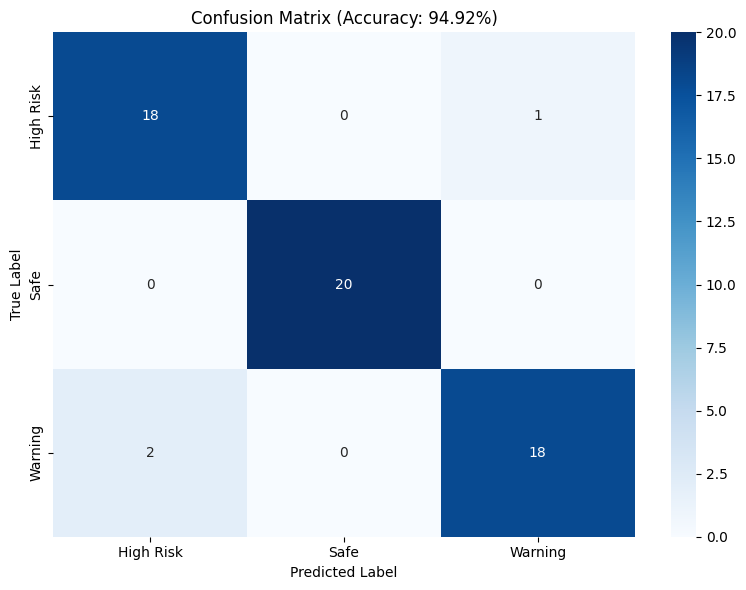

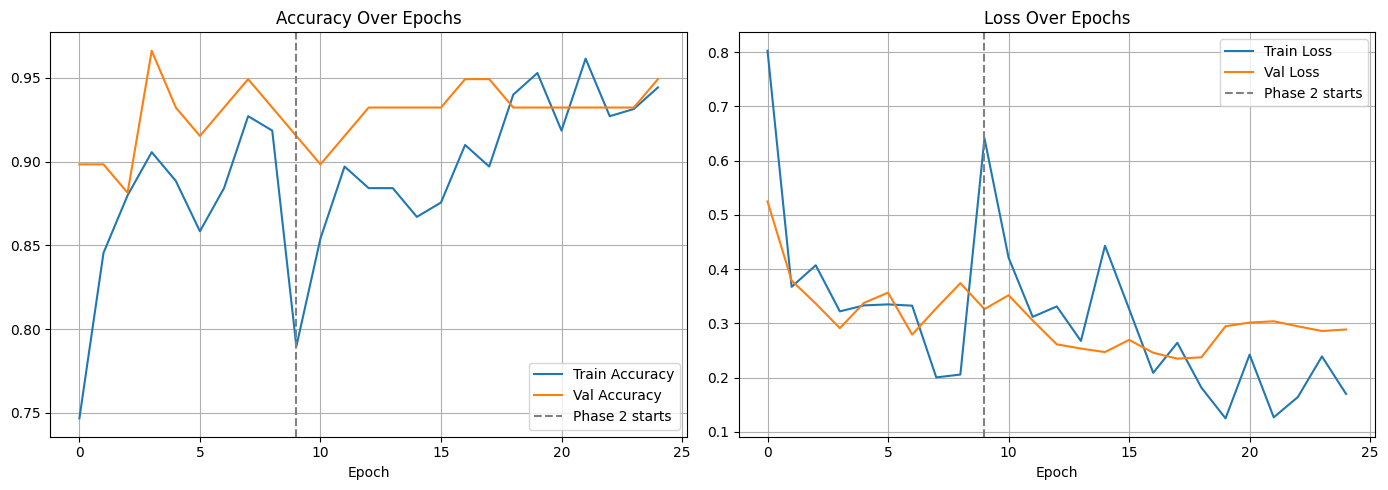


✅ Model saved as rockfall_final.keras
🏆 Final Accuracy: 94.92%


In [ ]:
# =========================
# 1️⃣ Upload & Extract
# =========================
from google.colab import files
uploaded = files.upload()
import zipfile, os, shutil, random, numpy as np
from PIL import Image
import tensorflow as tf

zip_path = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("raw_dataset")

# Auto-find dataset path
dataset_path = "raw_dataset"
for _ in range(3):
    items = [x for x in os.listdir(dataset_path) if not x.startswith('.')]
    if set(items) & {'Safe', 'Warning', 'High Risk'}:
        break
    dataset_path = os.path.join(dataset_path, items[0])
print("Dataset Path:", dataset_path)
print("Classes:", os.listdir(dataset_path))

# =========================
# 2️⃣ Clean Dataset
# =========================
import hashlib

print("\n🧹 Cleaning dataset...")
seen_hashes = {}
removed = 0

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(cls_path): continue

    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            img = Image.open(fpath).convert('RGB').resize((64,64))
            h = hashlib.md5(img.tobytes()).hexdigest()
            if h in seen_hashes:
                os.remove(fpath)
                removed += 1
            else:
                seen_hashes[h] = fpath
                orig = Image.open(fpath)
                if orig.mode != 'RGB':
                    orig.convert('RGB').save(fpath)
        except:
            os.remove(fpath)
            removed += 1

print(f"Removed {removed} duplicates/corrupt files")
for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if not f.startswith('.')])
        print(f"  {cls}: {count} images remaining")

# =========================
# 3️⃣ Train/Val Split
# =========================
print("\n📂 Creating clean train/val split...")
clean_path = "clean_dataset"
for split in ['train', 'val']:
    for cls in ['Safe', 'Warning', 'High Risk']:
        os.makedirs(os.path.join(clean_path, split, cls), exist_ok=True)

random.seed(42)
for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(cls_path): continue

    files_list = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    random.shuffle(files_list)

    split_idx = int(len(files_list) * 0.8)
    train_files = files_list[:split_idx]
    val_files = files_list[split_idx:]

    for f in train_files:
        shutil.copy2(os.path.join(cls_path, f),
                     os.path.join(clean_path, 'train', cls, f))
    for f in val_files:
        shutil.copy2(os.path.join(cls_path, f),
                     os.path.join(clean_path, 'val', cls, f))

    print(f"  {cls}: {len(train_files)} train, {len(val_files)} val")

# =========================
# 4️⃣ tf.data Pipeline
# =========================
img_size = 224
batch_size = 8
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.image.random_saturation(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(split, augment_data=False, shuffle=True):
    class_names = sorted([c for c in os.listdir(os.path.join(clean_path, split))
                          if not c.startswith('.')])
    class_to_idx = {c: i for i, c in enumerate(class_names)}

    paths, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(clean_path, split, cls)
        for f in sorted(os.listdir(cls_dir)):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(cls_dir, f))
                labels.append(class_to_idx[cls])

    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes=3)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(500)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds, class_names, labels

train_ds, class_names, train_labels = make_dataset('train', augment_data=True, shuffle=True)
val_ds, _, _ = make_dataset('val', augment_data=False, shuffle=False)  # ✅ No shuffle for val

print(f"\nClasses: {class_names}")
print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}")

# =========================
# 5️⃣ Class Weights
# =========================
from sklearn.utils.class_weight import compute_class_weight
unique_classes = np.unique(train_labels)
weights = compute_class_weight('balanced', classes=unique_classes, y=train_labels)
class_weights = dict(zip(unique_classes, weights))
print("Class weights:", class_weights)

# =========================
# 6️⃣ Build Model (ResNet50V2)
# =========================
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                      Dropout, BatchNormalization)
from tensorflow.keras.models import Model

base_model = ResNet50V2(weights='imagenet', include_top=False,
                         input_shape=(img_size, img_size, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# =========================
# 7️⃣ Phase 1: Train Head Only
# =========================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔵 PHASE 1: Warming up classifier head...")
h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping('val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau('val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
)

# =========================
# 8️⃣ Phase 2: Fine-tune Top Layers
# =========================
print("\n🟠 PHASE 2: Fine-tuning...")
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

h2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping('val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau('val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ]
)

# =========================
# 9️⃣ Correct Evaluation
# ✅ Uses fixed order dataset — no shuffle bug
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Build eval dataset with NO shuffle and sorted files
eval_ds, class_names, y_true_list = make_dataset('val', augment_data=False, shuffle=False)

val_loss, val_acc = model.evaluate(eval_ds)
print(f"\n✅ True Validation Accuracy: {val_acc:.4f} ({val_acc:.2%})")

y_pred_probs = model.predict(eval_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_true_list)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Accuracy: {val_acc:.2%})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Training Curves
all_acc = h1.history['accuracy'] + h2.history['accuracy']
all_val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
all_loss = h1.history['loss'] + h2.history['loss']
all_val_loss = h1.history['val_loss'] + h2.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(all_acc, label='Train Accuracy')
ax1.plot(all_val_acc, label='Val Accuracy')
ax1.axvline(len(h1.history['accuracy']), color='gray', linestyle='--', label='Phase 2 starts')
ax1.set_title('Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(all_loss, label='Train Loss')
ax2.plot(all_val_loss, label='Val Loss')
ax2.axvline(len(h1.history['loss']), color='gray', linestyle='--', label='Phase 2 starts')
ax2.set_title('Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# =========================
# 🔟 Save Model
# =========================
model.save("rockfall_final.keras")
print("\n✅ Model saved as rockfall_final.keras")
print(f"🏆 Final Accuracy: {val_acc:.2%}")

In [ ]:
import tensorflow as tf
from google.colab import files

# Upload the 3 files one by one
uploaded = files.upload()  # upload config.json
uploaded = files.upload()  # upload metadata.json
uploaded = files.upload()  # upload model.weights.h5

Saving config.json to config.json


Saving metadata.json to metadata.json


Saving model.weights.h5 to model.weights.h5


In [ ]:
# Upload the entire zip file
from google.colab import files
uploaded = files.upload()  # upload rockfall_final.keras.zip

import zipfile, os, tensorflow as tf

# Extract it
with zipfile.ZipFile("rockfall_final.keras.zip", 'r') as z:
    z.extractall("rockfall_final.keras")

# Load and resave as single file
model = tf.keras.models.load_model("rockfall_final.keras")

# Save as single H5 file
model.save("rockfall_model.h5")

# Download the single file
files.download("rockfall_model.h5")
print("✅ Done! Single file downloaded.")